# Manipulacija značajkama

In [1]:
import matplotlib.pyplot as plt
import numpy as np

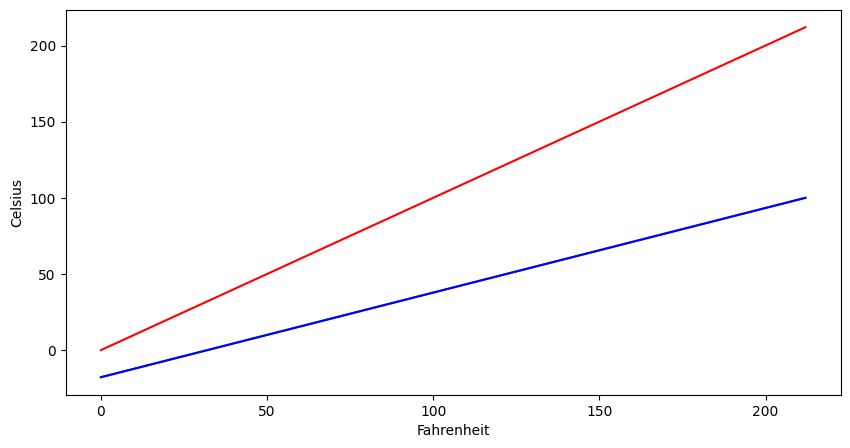

In [9]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
f_temp = np.linspace(0,212, 100)
c_temp = (5/9)*(f_temp-32)
ax.plot(f_temp, c_temp)
plt.plot(f_temp, f_temp, 'r', f_temp, c_temp, 'b')
ax.set_xlabel('Fahrenheit')
ax.set_ylabel('Celsius')
plt.show()

In [10]:
import pandas as pd
import seaborn as sns
from sklearn import preprocessing as skpre

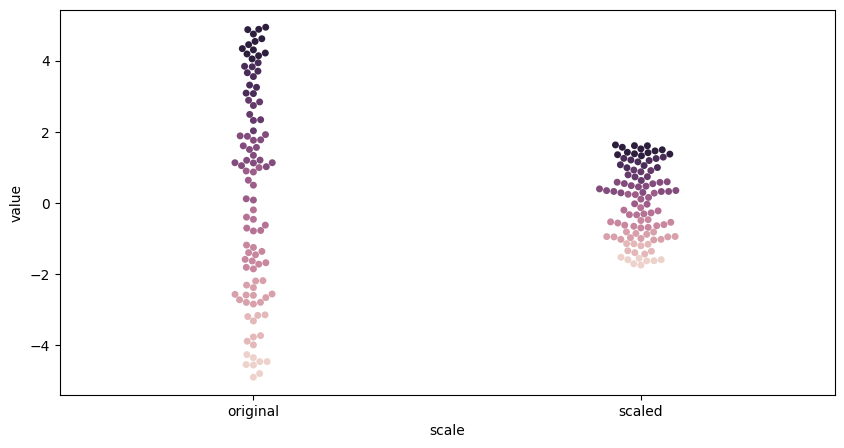

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
original = np.random.uniform(-5,5,100)
scaled = skpre.StandardScaler().fit_transform(original.reshape(-1,1))[:,0]
bins = np.floor(original).astype(np.uint8) + 5

df = pd.DataFrame({'original':original,
                   'scaled':scaled,
                   'hue':bins})
df = pd.melt(df, id_vars='hue', var_name='scale')

sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 48.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 24.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 56.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 31.3% of the points cannot be place

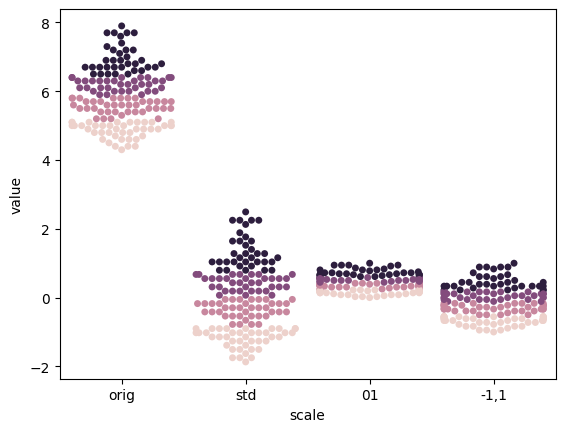

In [17]:
from sklearn import datasets
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
bins = pd.cut(iris_df['sepal length (cm)'], np.percentile(iris_df['sepal length (cm)'],[25,50,75,100])).cat.codes

df = pd.DataFrame({'orig':iris_df['sepal length (cm)'], 'hue':bins})

scalers = [('std', skpre.StandardScaler()), ('01', skpre.MinMaxScaler()), ('-1,1', skpre.MinMaxScaler((-1,1)))]

for name, scaler in scalers:
    df[name] = scaler.fit_transform(df[['orig']]).reshape(-1)

df = pd.melt(df, id_vars='hue', var_name='scale')
sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()


# Diskretizacija

In [18]:
# podaci se gube, pa nije baš preporučljiva za korištenje

In [19]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

iris_df['species'] = iris.target_names[iris.target]
display(iris_df.iloc[[0,50,100]])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


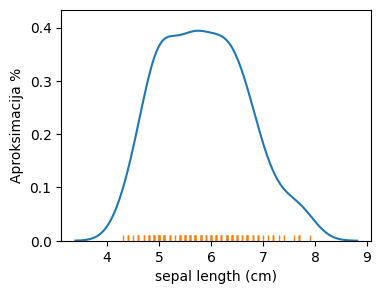

,sepal length (cm),> Mean
0,5.1,False
50,7.0,True
100,6.3,True


5.843333333333334


In [27]:
plt.figure(figsize=(4,3))
ax = sns.kdeplot(iris_df['sepal length (cm)'], fill=False)
sns.rugplot(iris_df['sepal length (cm)'])
ax.set_ylabel('Aproksimacija %')
plt.show()

column = iris_df[['sepal length (cm)']]
col_mean = column.mean().values[0]

both = column.copy()
both['> Mean'] = skpre.binarize(  column, threshold=col_mean).astype(bool)

display(both.iloc[[0,50,100]])
print(col_mean)

# Kategorijsko kodiranje

In [28]:
from sklearn import datasets, linear_model, preprocessing as skpre
from sklearn import model_selection as skms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
iris = datasets.load_iris()
(iris_train, iris_test, iris_train_tgt, iris_test_tgt) = train_test_split(iris.data, iris.target, test_size=0.25)

iris.feature_names = [fn[:-5] for fn in iris.feature_names]

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

print(iris.target[[0,50,100]])


sparse = skpre.OneHotEncoder().fit_transform(iris.target.reshape(-1,1)) # koristi se u pipeline

print(sparse[[0,50,100]].todense(), sep='\n')


encoded = pd.get_dummies(iris_df, prefix='is')
display(encoded.iloc[[0,50,100]])


target = "petal length"
X = encoded.drop(columns=[target])
y = encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))
r2=model.score(X_test, y_test)
print(r2) #97% modela je objašnjeno podacima - "dobro"

[0 1 2]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


,sepal length,sepal width,petal length,petal width,is_setosa,is_versicolor,is_virginica
0,5.1,3.5,1.4,0.2,True,False,False
50,7.0,3.2,4.7,1.4,False,True,False
100,6.3,3.3,6.0,2.5,False,False,True


0.08787176438628266
0.9731884840751769


# Multikolinearnost

In [38]:
from sklearn import datasets, linear_model, preprocessing as skpre
from sklearn import model_selection as skms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.DataFrame({'grad':['Zagreb', 'Split', 'Rijeka'], 'cijena':[100, 120, 90]})
X = df[['grad']]
y = df['cijena']


#ohe = skpre.OneHotEncoder(drop=None, sparse_output=False) # mora se izbacit jedan stupac jer model postaje nestabilan

ohe = skpre.OneHotEncoder(drop='first', sparse_output=False)

Z = ohe.fit_transform(X)

lr = LinearRegression()
lr.fit(Z, y)

print(lr.coef_)
print(lr.intercept_)


[30. 10.]
90.0


# Primjer dijamanti

In [50]:
from sklearn import datasets, linear_model, preprocessing as skpre
from sklearn import model_selection as skms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [45]:
df = sns.load_dataset('diamonds').dropna()
display(df.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [47]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [54]:
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

X1 = df[num_cols]
y1 = df['price']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)
print(mean_squared_error(y1_test, y1_pred))
r2 = model1.score(X1_test, y1_test)
print(r2)


pre = ColumnTransformer(
    transformers=[
    ('cat', skpre.OneHotEncoder(drop='first', handle_unknown= 'ignore'),  cat_cols),
    ('num', "passthrough", num_cols),
], remainder="drop")


model2 = Pipeline(steps=[
    ('pre', pre),
    ('lin', LinearRegression())
])


print("--------------------------------------------------")
X2 = df[num_cols + cat_cols]
y2 = df['price']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)
print(mean_squared_error(y2_test, y2_pred))
r2 = model2.score(X2_test, y2_test)
print(r2)



2242178.9040856035
0.8589542625888938
--------------------------------------------------
1288705.477851674
0.9189331350419387
